# Dry Bean: package-executed Multi-IMV example

This notebook executes `imv.MulticlassIMV` on the local processed dataset and creates both figures from the fresh fold results. No result pickle is loaded. Three shuffled folds keep the notebook interactive; use ten folds and the documented seeds for full paper reproduction.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imv import MulticlassIMV
HERE=Path.cwd(); DATA=HERE.parent/"data"; FIGURES=HERE/"figures"; FIGURES.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
data=pd.read_csv(DATA/"dry_bean_processed.csv")
features=[column for column in data.columns if column!="target"]
print(data.shape, features, sorted(data["target"].unique()))
data.head()

(13611, 17) ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4'] [0, 1, 2, 3, 4, 5, 6]


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,target
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,0
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,0
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,0
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,0
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,0


In [3]:
evaluator=MulticlassIMV(data,"target",lambda:LogisticRegression(max_iter=2000,random_state=42),n_splits=3,optional_explanatory_variables=features,random_state=42,stratified=False,verbose=False)
ova_folds,ova_mean=evaluator.k_fold_one_vs_all()
matrix_folds,matrix_mean=evaluator.k_fold_imv_matrix()
pd.DataFrame({"class":matrix_mean.index,"one_vs_rest_imv":ova_mean})

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,class,one_vs_rest_imv
0,0,0.162796
1,1,0.093982
2,2,0.038935
3,3,0.123019
4,4,0.318417
5,5,0.152610
6,6,0.197296


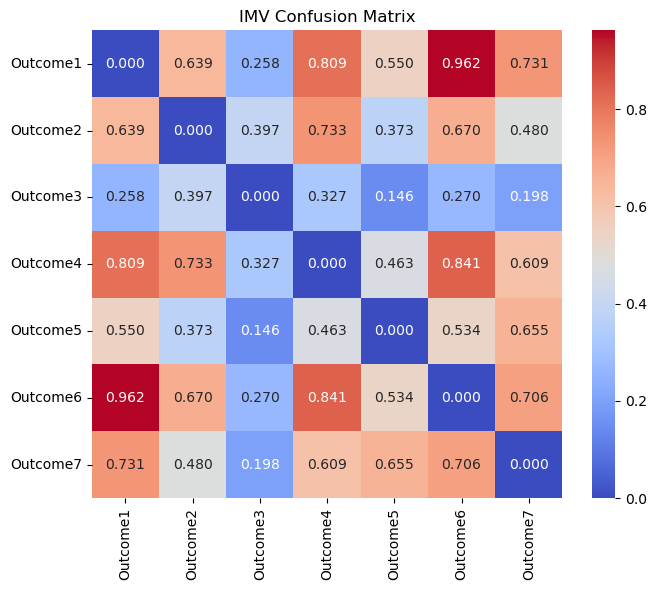

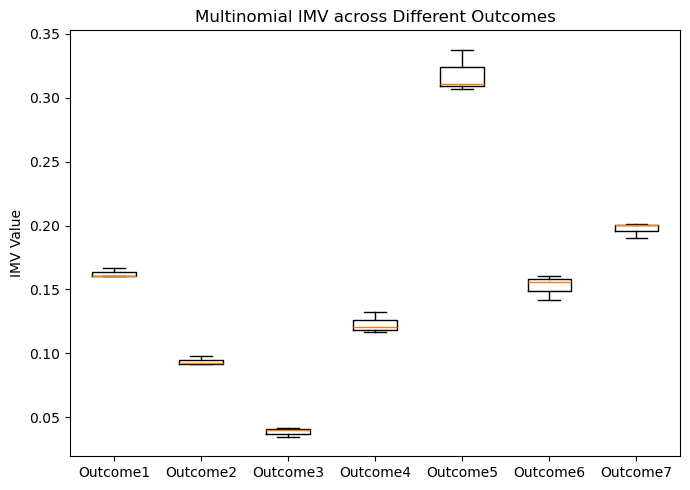

(PosixPath('/Users/valler/Python/imv_ml_package/examples/multi_imv/figures/multi_imv_dry_bean_package_heatmap.png'),
 PosixPath('/Users/valler/Python/imv_ml_package/examples/multi_imv/figures/multi_imv_dry_bean_package_boxplot.png'))

In [4]:
fig1,ax1=evaluator.multinomial_IMV_heatmap(matrix_mean,figsize=(7,6)); fig1.tight_layout(); heatmap_path=FIGURES/"multi_imv_dry_bean_package_heatmap.png"; fig1.savefig(heatmap_path,dpi=180,bbox_inches="tight"); plt.show()
fig2,ax2=evaluator.multinomial_IMV_boxplot(ova_folds,figsize=(7,5)); fig2.tight_layout(); boxplot_path=FIGURES/"multi_imv_dry_bean_package_boxplot.png"; fig2.savefig(boxplot_path,dpi=180,bbox_inches="tight"); plt.show()
heatmap_path,boxplot_path